In [1]:
from pathlib import Path

from ase.io import read
from ase import Atoms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("../mpl_themes/jvc.mplstyle")

O objetivo deste Jupyter Notebook será o de analisar a composição do dataset utilizado pra produzir as bandas do modelo007, no qual utilizou-se alguns subsets e um filtro de força de 20 e $\text{eV}/\AA$.

<!-- <div align="center"> -->

<!-- 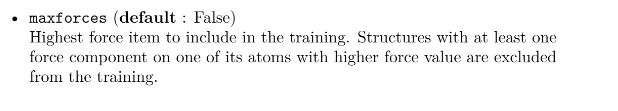 -->

<!-- </div> -->

In [2]:
# Paths
# train        = 6254 estruturas (Original Sampling)
# subset1      = 221  (1x1x8)
# subset2      = 49   (2x1x4)
# subset3      = 78   (3x3x3)
# normal_modes = 10
# -----------------------------------
# 6612 estruturas.

data = Path("/home/jvc/ZnO_database/data")

train = data / "dataset" / "01_LDA_dataset_filtered" / "train"
subsets_names = [
    "LDA_118_XSF",
    "LDA_214_XSF",
    "LDA_333_XSF",
    "LDA_normal_modes_3x3x3",
]

subsets: list[Path] = [data / f"subsets/{s}" for s in subsets_names]
xsf_dirs: list[Path] = [train, *subsets]
all_files: list[Path] = [file for d in xsf_dirs for file in sorted(d.glob("*.xsf"))]
atoms = [read(f) for f in all_files]

In [3]:
print(all_files)
print(len(all_files))

[PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf'), PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0003-ZnO-113-fa0.90-fc0.90-n0.000.xsf'), PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0005-ZnO-212-fa0.90-fc0.90-n0.000.xsf'), PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0007-ZnO-221-fa0.90-fc0.90-n0.000.xsf'), PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0009-ZnO-311-fa0.90-fc0.90-n0.000.xsf'), PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0010-ZnO-312-fa0.90-fc0.90-n0.000.xsf'), PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0011-ZnO-313-fa0.90-fc0.90-n0.000.xsf'), PosixPath('/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0013-ZnO-331-fa0.90-fc0.90-n0.000.xsf'), PosixPath('/home/jvc/Zn

In [4]:
def get_force_df(atoms: list[Atoms], filenames: list[Path]) -> pd.DataFrame:
    """Return a long dataframe containing all the forces acting on a list of atoms."""

    dados_forcas = []

    for i, snapshot in enumerate(atoms):
        forces = snapshot.get_forces()

        for idx_atomo, vetor_forca in enumerate(forces):
            symbols: list[str] = snapshot.get_chemical_symbols()
            dados_forcas.append({
                "filename": filenames[i].name,  # Número do snapshot (0, 1, 2...)
                "atom": symbols[idx_atomo],  # Índice do átomo dentro do frame
                "fx": vetor_forca[0],
                "fy": vetor_forca[1],
                "fz": vetor_forca[2],
            })

    df_forcas = pd.DataFrame(dados_forcas)
    return df_forcas

In [5]:
forces = get_force_df(atoms=atoms, filenames=all_files)

# Filtro do aenet-PyTorch
forces["atomo_valido"] = (forces.iloc[:, 2:].abs() <= 20).all(axis=1)

print("Amostra do Dataframe filtrando por força no átomo:\n")
display(forces.sample(10))

df_estruturas = forces.groupby("filename")[["atomo_valido"]].all().reset_index()
df_estruturas = df_estruturas.rename(columns={"atomo_valido": "estrutura_valida"})

print("Amostra do Dataframe filtrando por estrutura válida:\n")
display(df_estruturas)

Amostra do Dataframe filtrando por força no átomo:



,filename,atom,fx,fy,fz,atomo_valido
54636,LDA-3536-ZnO-331-fa0.94-fc1.04-n0.060.xsf,Zn,-16.119498,-10.142486,28.408660,False
56618,LDA-3665-ZnO-321-fa0.96-fc1.02-n0.060.xsf,O,-121.765759,85.968500,-4.445726,False
23108,LDA-1492-ZnO-312-fa1.10-fc0.98-n0.000.xsf,Zn,0.000028,0.000014,1.020890,True
57761,LDA-3742-ZnO-313-fa0.98-fc0.92-n0.060.xsf,Zn,5.974801,-2.844042,-253.044831,False
11296,LDA-0732-ZnO-211-fa1.00-fc0.92-n0.000.xsf,Zn,0.000042,0.000021,-43.530607,False
21530,LDA-1383-ZnO-212-fa1.08-fc1.04-n0.000.xsf,O,0.000035,0.000021,2.004392,True
57454,LDA-3720-ZnO-112-fa0.98-fc0.90-n0.060.xsf,O,18.767216,-16.989750,62.571933,False
5698,LDA-0370-ZnO-213-fa0.94-fc1.02-n0.000.xsf,O,0.000000,0.000000,-10.949260,True
36355,LDA-2340-ZnO-331-fa1.00-fc0.96-n0.040.xsf,O,-6.745790,-6.916584,55.129204,False
22945,LDA-1480-ZnO-313-fa1.10-fc0.96-n0.000.xsf,Zn,-0.000070,-0.000042,0.359268,True


Amostra do Dataframe filtrando por estrutura válida:



,filename,estrutura_valida
0,LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf,False
1,LDA-0001-ZnO-118-fa0.90-fc0.90-n0.000.xsf,True
2,LDA-0001-ZnO-214-fa0.95-fc0.95-n0.000.xsf,True
3,LDA-0001-ZnO-333-fa0.95-fc0.95-n0.000.xsf,True
4,LDA-0002-ZnO-118-fa0.90-fc0.90-n0.040.xsf,False
...,...,...
5296,LDA-6288-ZnO-311-fa1.10-fc1.10-n0.120.xsf,False
5297,LDA-6289-ZnO-312-fa1.10-fc1.10-n0.120.xsf,False
5298,LDA-6290-ZnO-313-fa1.10-fc1.10-n0.120.xsf,False
5299,LDA-6291-ZnO-321-fa1.10-fc1.10-n0.120.xsf,False


In [6]:
df_estruturas["estrutura_valida"] = df_estruturas["estrutura_valida"].map({
    True: "sim",
    False: "não",
})
display(df_estruturas)

,filename,estrutura_valida
0,LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf,não
1,LDA-0001-ZnO-118-fa0.90-fc0.90-n0.000.xsf,sim
2,LDA-0001-ZnO-214-fa0.95-fc0.95-n0.000.xsf,sim
3,LDA-0001-ZnO-333-fa0.95-fc0.95-n0.000.xsf,sim
4,LDA-0002-ZnO-118-fa0.90-fc0.90-n0.040.xsf,não
...,...,...
5296,LDA-6288-ZnO-311-fa1.10-fc1.10-n0.120.xsf,não
5297,LDA-6289-ZnO-312-fa1.10-fc1.10-n0.120.xsf,não
5298,LDA-6290-ZnO-313-fa1.10-fc1.10-n0.120.xsf,não
5299,LDA-6291-ZnO-321-fa1.10-fc1.10-n0.120.xsf,não


In [7]:
df_validas = df_estruturas.query("estrutura_valida == 'sim' ")
df_validas = df_validas.reset_index(drop=True)
display(df_validas)

,filename,estrutura_valida
0,LDA-0001-ZnO-118-fa0.90-fc0.90-n0.000.xsf,sim
1,LDA-0001-ZnO-214-fa0.95-fc0.95-n0.000.xsf,sim
2,LDA-0001-ZnO-333-fa0.95-fc0.95-n0.000.xsf,sim
3,LDA-0002-ZnO-214-fa0.95-fc0.97-n0.000.xsf,sim
4,LDA-0002-ZnO-333-fa0.95-fc0.97-n0.000.xsf,sim
...,...,...
1207,LDA-4707-ZnO-111-fa1.10-fc1.10-n0.060.xsf,sim
1208,LDA-4711-ZnO-212-fa1.10-fc1.10-n0.060.xsf,sim
1209,LDA-5968-ZnO-111-fa1.06-fc1.06-n0.120.xsf,sim
1210,LDA-6111-ZnO-111-fa1.08-fc1.06-n0.120.xsf,sim


In [8]:
count_estruturas = df_estruturas["estrutura_valida"].value_counts()
count_estruturas.index = ("Invalid", "Valid")

print(f"Contagem estruturas:\n{count_estruturas}\n")


Contagem estruturas:
Invalid    4089
Valid      1212
Name: count, dtype: int64



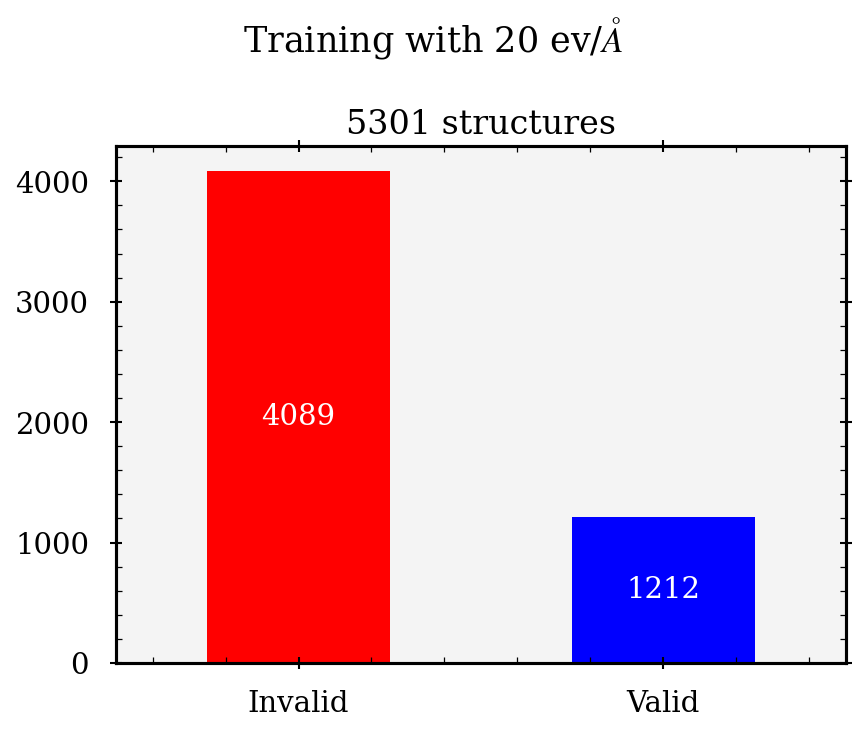

In [9]:
fig, ax = plt.subplots()
fig.suptitle(r"Training with 20 ev/$\AA$")
ax.set_title(f"{df_estruturas.shape[0]} structures")
ax.set_facecolor("#f4f4f4")
count_estruturas.plot(kind="bar", ax=ax, rot=0, color=["red", "blue"])
ax.bar_label(container=ax.containers[0], label_type="center", color="white")
ax.tick_params(direction="inout")
plt.show()

---

##  Células unitárias (vindas do template)

Meu template seria o arquivo: `LDA-0781-ZnO-111-fa1.00-fc1.00-n0.000.xsf` com  $a = 3.2\AA$ e $c=5.13 \AA$

In [10]:
complete_dataset: Path = train.parent.parent / "01_LDA_dataset"

unit_cell_files: list[Path] = [
    file for d in [complete_dataset] for file in sorted(d.glob("*ZnO-111-*-n0.000.xsf"))
]
print(*unit_cell_files[:3], sep="\n")

unit_cell_atoms: list[Atoms] = [read(f) for f in unit_cell_files]
print(*unit_cell_atoms[:3], sep="\n")

/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0014-ZnO-111-fa0.90-fc0.92-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset/LDA-0027-ZnO-111-fa0.90-fc0.94-n0.000.xsf
Atoms(symbols='Zn2O2', pbc=True, cell=[[2.876560207838307, 0.0, 0.0], [-1.4382801039191535, 2.49117305399317, 0.0], [0.0, 0.0, 4.156482795755754]], calculator=SinglePointCalculator(...))
Atoms(symbols='Zn2O2', pbc=True, cell=[[2.876560207838307, 0.0, 0.0], [-1.4382801039191535, 2.49117305399317, 0.0], [0.0, 0.0, 4.248849144029442]], calculator=SinglePointCalculator(...))
Atoms(symbols='Zn2O2', pbc=True, cell=[[2.876560207838307, 0.0, 0.0], [-1.4382801039191535, 2.49117305399317, 0.0], [0.0, 0.0, 4.34121549230313]], calculator=SinglePointCalculator(...))


In [11]:
df_unit_cell = pd.DataFrame({
    "filenames": [f.name for f in unit_cell_files],
    "atoms": unit_cell_atoms,
})
display(df_unit_cell)

,filenames,atoms
0,LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.155833556..."
1,LDA-0014-ZnO-111-fa0.90-fc0.92-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.248185521..."
2,LDA-0027-ZnO-111-fa0.90-fc0.94-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.340537487..."
3,LDA-0040-ZnO-111-fa0.90-fc0.96-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.432889164..."
4,LDA-0053-ZnO-111-fa0.90-fc0.98-n0.000.xsf,"(Atom('Zn', [-0.0, 1.660782898964, 4.525241130..."
...,...,...
116,LDA-1509-ZnO-111-fa1.10-fc1.02-n0.000.xsf,"(Atom('Zn', [-0.0, 2.029846003027, 5.756599841..."
117,LDA-1522-ZnO-111-fa1.10-fc1.04-n0.000.xsf,"(Atom('Zn', [-0.0, 2.029846003027, 5.869474479..."
118,LDA-1535-ZnO-111-fa1.10-fc1.06-n0.000.xsf,"(Atom('Zn', [-0.0, 2.029846003027, 5.982348765..."
119,LDA-1548-ZnO-111-fa1.10-fc1.08-n0.000.xsf,"(Atom('Zn', [-0.0, 2.029846003027, 6.095223403..."


In [12]:
# x here is a Atoms obj from ASE 
df_unit_cell["a"] = df_unit_cell["atoms"].apply(lambda x: x.cell[0][0])
df_unit_cell["c"] = df_unit_cell["atoms"].apply(lambda x: x.cell[2][2])

In [13]:
# # Avoid "duplicate" roundoff erros
# df_unit_cell["a"] = df_unit_cell["a"]
# df_unit_cell["c"] = df_unit_cell["c"]

In [14]:
unique_a = sorted(df_unit_cell["a"].unique())
unique_c = sorted(df_unit_cell["c"].unique())


print(f"Unique values of a ({len(unique_a)}):\n{unique_a}")
print(f"Unique values of c ({len(unique_c)}):\n{unique_c}")

Unique values of a (11):
[2.876560207838307, 2.9404842854302067, 3.004407833844898, 3.068331382259589, 3.13225493067428, 3.196178479088971, 3.2601020275036623, 3.3240255759183532, 3.387949124333044, 3.4518726727477356, 3.5157962211624265]
Unique values of c (121):
[4.156482795755754, 4.248849144029442, 4.248849827748092, 4.34121549230313, 4.341216095106351, 4.343268778153256, 4.433581840576818, 4.433582362464611, 4.437687630651111, 4.437687728558419, 4.5259481888505055, 4.52594862982287, 4.532106483148966, 4.532106678963584, 4.534159166195871, 4.618314537124194, 4.618314897181129, 4.626525335646821, 4.626525629368747, 4.630630603833322, 4.630630701740631, 4.710680885397882, 4.710681164539389, 4.720944188144676, 4.720944579773912, 4.727102041470772, 4.72710223728539, 4.729154724517677, 4.80304723367157, 4.803047431897649, 4.815363040642532, 4.815363530179075, 4.823573479108223, 4.82357377283015, 4.827678747294724, 4.8276788452020325, 4.89541070538505, 4.895413699255908, 4.90978189314038

In [15]:
# 11 a's to 11 c's
df_unit_cell.groupby("a")[["c"]].count()

,c
a,
2.876560,11
2.940484,11
3.004408,11
3.068331,11
3.132255,11
3.196178,11
3.260102,11
3.324026,11
3.387949,11


In [16]:
df_unit_cell["strain_a (%)"] = ((df_unit_cell["a"] - 3.20) / 3.20) * 100
df_unit_cell["strain_c (%)"] = ((df_unit_cell["c"] - 5.13) / 5.13) * 100
df_unit_cell["strain_a (%)"] = df_unit_cell["strain_a (%)"]
df_unit_cell["strain_c (%)"] = df_unit_cell["strain_c (%)"]


In [17]:
# TEMPLATE STRUCTURE

print("-" * 80)
print("Equilibrium Structure\n")
print(df_unit_cell.iloc[60])

print("-" * 80)
print("Forces acting on atoms (eV/angstrom):\n")
print(df_unit_cell.iloc[60]["atoms"].get_forces())
print("-" * 80)


--------------------------------------------------------------------------------
Equilibrium Structure

filenames               LDA-0781-ZnO-111-fa1.00-fc1.00-n0.000.xsf
atoms           (Atom('Zn', [-0.0, 1.845314603756, 5.130659750...
a                                                        3.196178
c                                                        5.131461
strain_a (%)                                            -0.119423
strain_c (%)                                             0.028486
Name: 60, dtype: object
--------------------------------------------------------------------------------
Forces acting on atoms (eV/angstrom):

[[ 0.          0.          0.00204293]
 [-0.          0.          0.00204293]
 [ 0.          0.         -0.00204293]
 [ 0.          0.         -0.00204293]]
--------------------------------------------------------------------------------


In [18]:
amin = df_unit_cell["a"].min()
amax = df_unit_cell["a"].max()


cmin = df_unit_cell["c"].min()
cmax = df_unit_cell["c"].max()

min_strain_a = df_unit_cell["strain_a (%)"].min()
max_strain_a = df_unit_cell["strain_a (%)"].max()

min_strain_c = df_unit_cell["strain_c (%)"].min()
max_strain_c = df_unit_cell["strain_c (%)"].max()


print(amin, amax)
print(cmin, cmax)
print()
print(min_strain_a, max_strain_a)
print(min_strain_c, max_strain_c)


2.876560207838307 3.5157962211624265
4.156482795755754 6.209064884791461

-10.107493505052911 9.868631911325823
-18.97694355251941 21.034403212309186


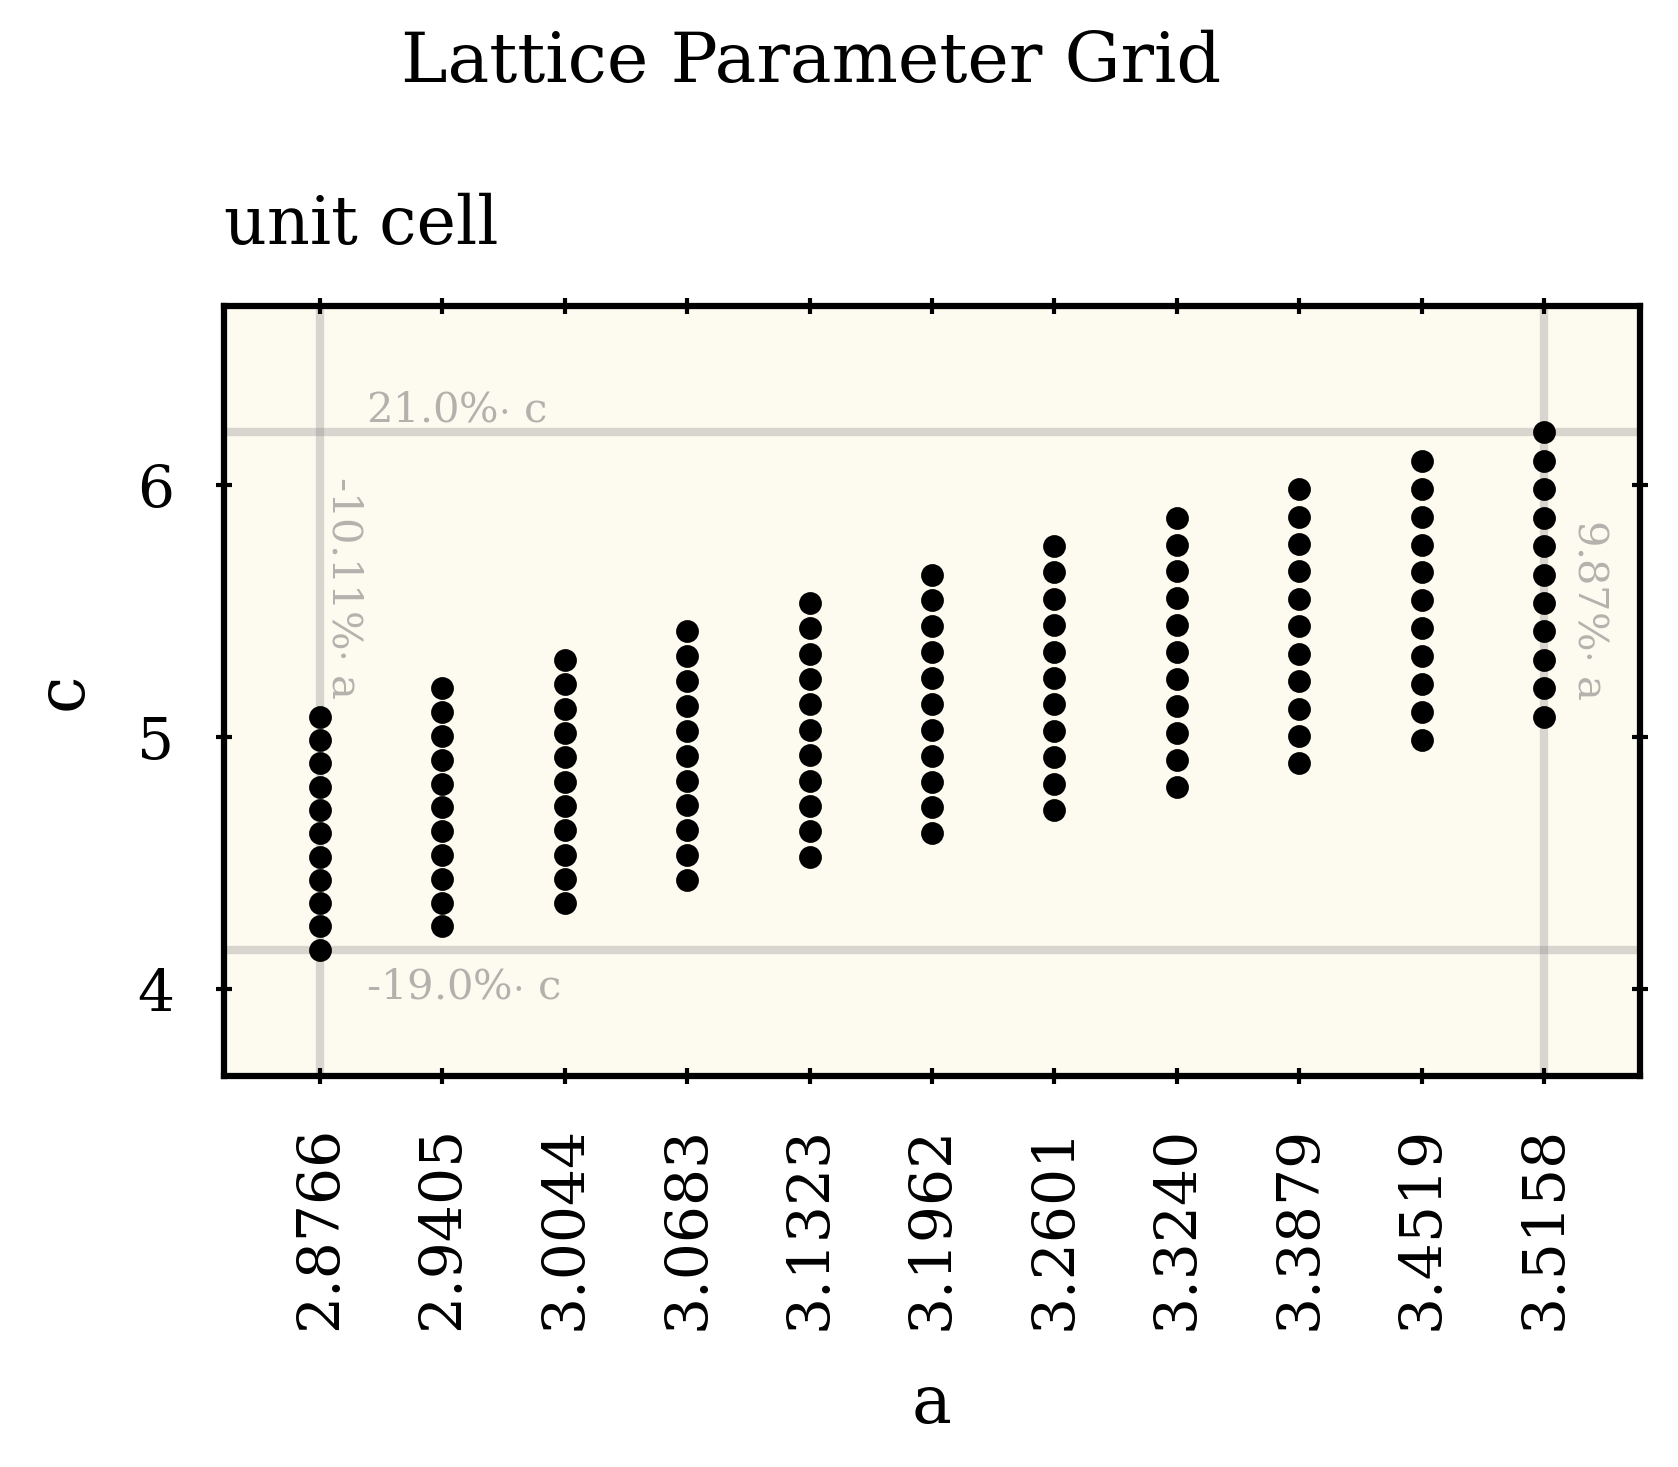

In [19]:
fig, ax = plt.subplots(dpi=300)
fig.suptitle("Lattice Parameter Grid")
ax.set_title("unit cell", pad=15, loc="left")
df_unit_cell.plot(kind="scatter", x="a", y="c", ax=ax, color="black")
ax.set_xticks(unique_a)

ax.set_ylim([cmin - 0.5, cmax + 0.5])
ax.set_xlim([amin - 0.05, amax + 0.05])

ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="both", which="minor", length=0)
ax.tick_params(axis="both", which="major", length=4, direction="inout")

# Lattice parameter a
lines_style = dict(color="gray", alpha=0.3, ls="-", zorder=0)
text_style = dict(rotation=-90, color="dimgray", alpha=0.5, size=10)

text_min = f"{min_strain_a:.2f}%" + r"$\cdot$" + " a"
text_max = f"{max_strain_a:.2f}%" + r"$\cdot$" + " a"

ax.axvline(amin, **lines_style)
ax.axvline(amax, **lines_style)
ax.text(transform=ax.transAxes, x=0.07, y=0.5, s=text_min, **text_style)
ax.text(transform=ax.transAxes, x=0.95, y=0.5, s=text_max, **text_style)


# Lattice parameter c
text_style = dict(rotation=0, color="dimgrey", alpha=0.5, size=10)
lines_style = dict(color="gray", alpha=0.3, ls="-",zorder=0)

text_min = f"{min_strain_c:.1f}%" + r"$\cdot$" + " c"
text_max = f"{max_strain_c:.1f}%" + r"$\cdot$" + " c"

ax.axhline(cmin, **lines_style)
ax.axhline(cmax, **lines_style)

ax.text(transform=ax.transAxes, x=0.10, y=0.10, s=text_min, **text_style)
ax.text(transform=ax.transAxes, x=0.10, y=0.85, s=text_max, **text_style)
# ax.text(transform=ax.transAxes, x=0.10, y=0.80)

plt.show()

Pelo visto eu criei um strain meio maluco... no plano parece ir de -10% a 10%, na mas na vertical vai de -19% a 21% mas com valores diferentes para cada $a$ comprimido/esticado!

In [20]:
df_unit_cell.drop(columns="atoms").to_csv("unit_cells.csv", index=False, sep=" ")


## Análise do dataset filtrado em 20 eV /$\AA$

Responderemos as seguintes perguntas para analisar o dataset utilizado para dispersão de fônons com o **model006**.

- Qual a contagem do fatores de strain $f_a$ ? E $f_c$ ?
    - Levar em consideração que são "errados" com base na análise acima.
- Qual a contribuição de cada $\sigma$? 
- Existe alguma distinção a nível do tamanho da supercélula?? 



In [21]:
df_validas["shape"] = df_validas["filename"].apply(lambda x: x.split("-")[3])
df_validas["shape"] = df_validas["shape"].apply(lambda x: "x".join(x))

df_validas["fa"] = (
    df_validas["filename"].apply(lambda x: x.split("-")[4][2:]).astype(float)
)
df_validas["fc"] = (
    df_validas["filename"].apply(lambda x: x.split("-")[5][2:]).astype(float)
)
df_validas["sigma"] = (
    df_validas["filename"].apply(lambda x: x.split("-")[6][1:-4]).astype(float)
)  # remove sufixo e '.' (-4) e n [1:
df_validas

,filename,estrutura_valida,shape,fa,fc,sigma
0,LDA-0001-ZnO-118-fa0.90-fc0.90-n0.000.xsf,sim,1x1x8,0.90,0.90,0.00
1,LDA-0001-ZnO-214-fa0.95-fc0.95-n0.000.xsf,sim,2x1x4,0.95,0.95,0.00
2,LDA-0001-ZnO-333-fa0.95-fc0.95-n0.000.xsf,sim,3x3x3,0.95,0.95,0.00
3,LDA-0002-ZnO-214-fa0.95-fc0.97-n0.000.xsf,sim,2x1x4,0.95,0.97,0.00
4,LDA-0002-ZnO-333-fa0.95-fc0.97-n0.000.xsf,sim,3x3x3,0.95,0.97,0.00
...,...,...,...,...,...,...
1207,LDA-4707-ZnO-111-fa1.10-fc1.10-n0.060.xsf,sim,1x1x1,1.10,1.10,0.06
1208,LDA-4711-ZnO-212-fa1.10-fc1.10-n0.060.xsf,sim,2x1x2,1.10,1.10,0.06
1209,LDA-5968-ZnO-111-fa1.06-fc1.06-n0.120.xsf,sim,1x1x1,1.06,1.06,0.12
1210,LDA-6111-ZnO-111-fa1.08-fc1.06-n0.120.xsf,sim,1x1x1,1.08,1.06,0.12


### Qual a contribuição de cada strain ?

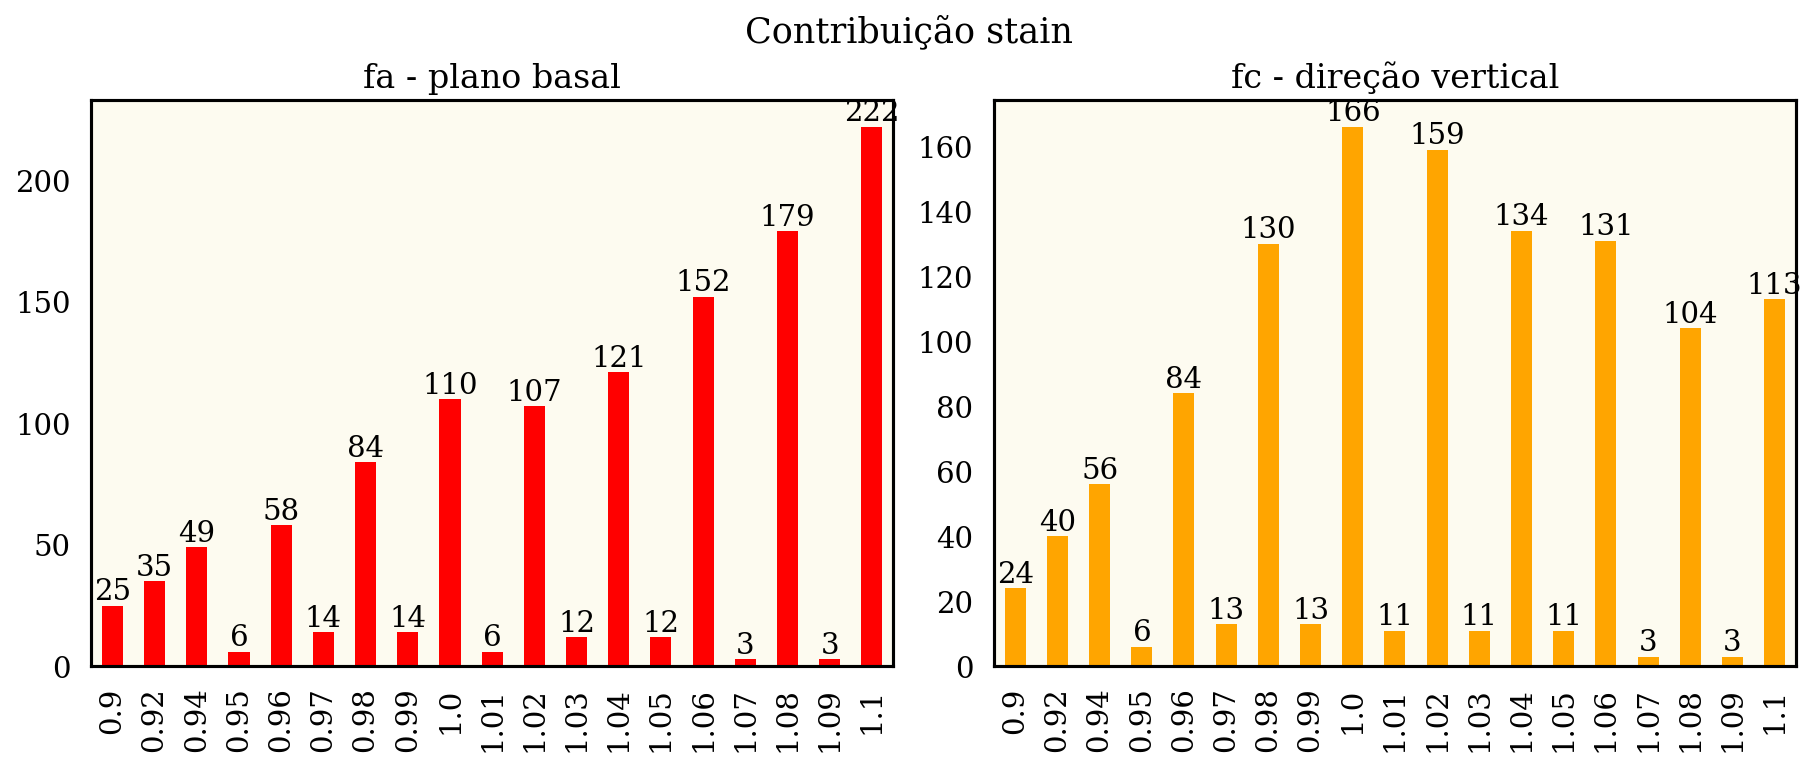

In [22]:
fig, (ax1, ax2) = plt.subplots(figsize=(12, 5), ncols=2, layout="constrained")
fig.suptitle("Contribuição stain")
ax1.set_title("fa - plano basal")
ax2.set_title("fc - direção vertical")

df_validas.groupby("fa")["filename"].count().plot(
    kind="bar", ax=ax1, rot=90, color="red"
)
df_validas.groupby("fc")["filename"].count().plot(
    kind="bar", ax=ax2, rot=90, color="orange"
)

for ax in (ax1, ax2):
    ax.tick_params(axis="both", which="both", length=0)
    ax.bar_label(ax.containers[0], color="black")
    ax.set_xlabel("")
plt.show()


Bom, aqui tirando as barrinhas pequenas com valores ímpares de $fa$ e $fc$  ue eu produzi já na fase da criação de subset para ajeitar os fônons:

- para o $fa$ é uma crescente ↗️.
- para o $fc$ o comportamento é diferente


Mas vale pontuar que, por conta do strain "estranho" não necessariamente o $fc$ pode equivaler ao strain real aplicado a vetor $c$ da rede. Com o $a$ e $b$ do plano, pelo menos, isso é garantia!



### Qual a contribuição de cada ruído aleatório??

In [23]:
count_by_sigma = df_validas.groupby("sigma")[["filename"]].count()
display(count_by_sigma)


,filename
sigma,
0.00,970
0.04,186
0.06,53
0.12,3


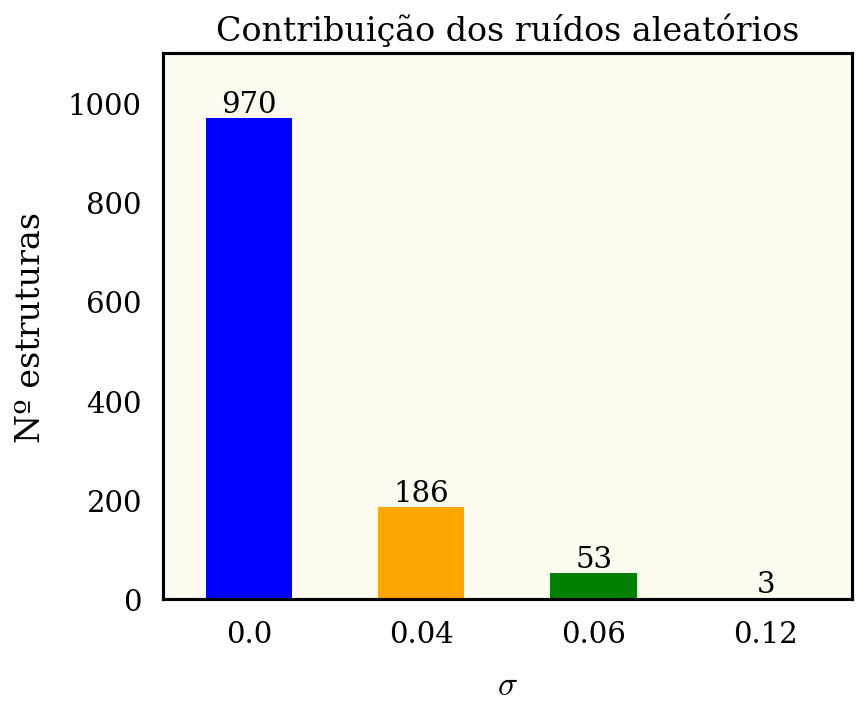

In [24]:
cores = ["blue", "orange", "green", "red"]

fig, ax = plt.subplots()
ax.set_title("Contribuição dos ruídos aleatórios")

count_by_sigma["filename"].plot(ax=ax, kind="bar", color=cores, rot=0)

ax.bar_label(ax.containers[0], color="black")
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel("Nº estruturas")
ax.set_ylim([0, 1100])
ax.tick_params(axis="both", which="both", length=0)
plt.show()

Percebe-se que para o filtro, os delocamentos aleatórios **REALMENTE** impactam nas forças. O valor de $0.12$ ficou com apenas **3 estruturas**.

## Contagem por tamanho da supercélula

In [25]:
count_by_shape = df_validas.groupby("shape")[["filename"]].count()

count_by_shape = count_by_shape.rename(columns={"filename": "contagem"})
count_by_shape = count_by_shape.sort_values(by="contagem", ascending=True)
count_by_shape

,contagem
shape,
2x1x4,41
3x3x3,50
1x1x8,66
3x1x3,66
2x1x3,72
2x2x2,72
3x3x1,73
3x1x2,75
2x2x1,76


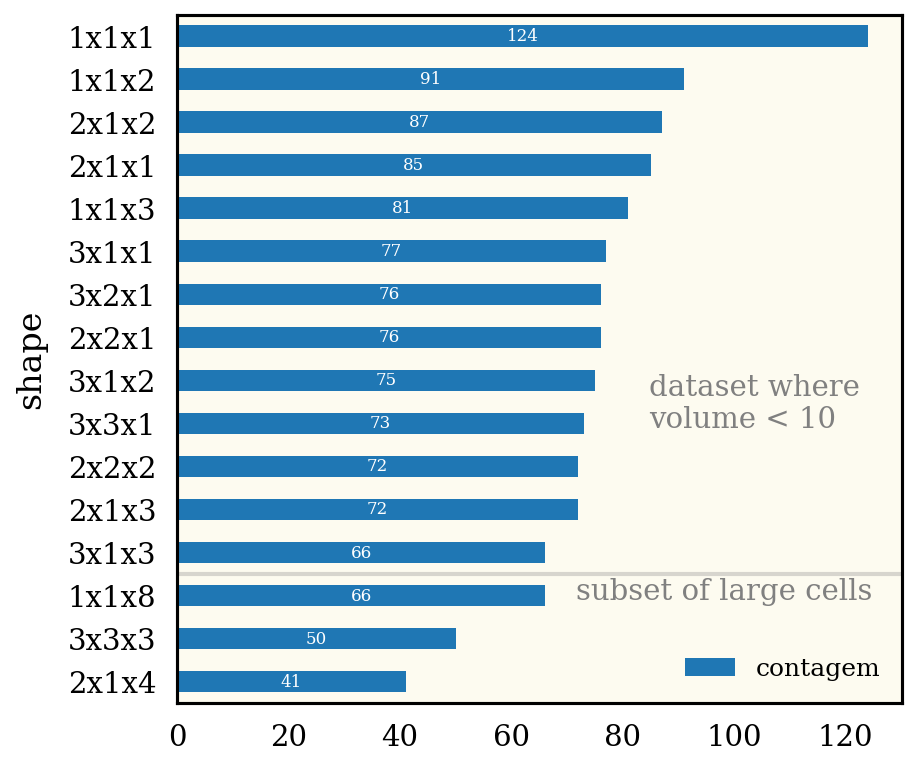

In [26]:
fig, ax = plt.subplots(layout="constrained")
count_by_shape.plot(ax=ax, kind="barh")
ax.tick_params(axis="both", which="both", length=0)
ax.bar_label(ax.containers[0], label_type="center", size=8, color="white")

ax.axhline(2.5, **lines_style)
ax.text(transform=ax.transAxes, x=0.65, y=0.4, s="dataset where\nvolume < 10", color="gray")
ax.text(transform=ax.transAxes, x=0.55, y=0.15, s="subset of large cells", color="gray")
plt.show()

Não há uma tendência/bias aparente no tamanho da supercélulas.. exceto pelas 1x1x1 que conta com mais contribuições.